/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Processing 215...
  AD agg p=0.0100  n_z=17,000  bins=17 (6% pass)
Processing 213...
  AD agg p=0.0100  n_z=17,000  bins=17 (71% pass)
Processing 209...
  AD agg p=0.0100  n_z=17,000  bins=17 (0% pass)
Processing 203...
  AD agg p=0.0100  n_z=17,000  bins=17 (0% pass)
Processing 210...
  AD agg p=0.0100  n_z=17,000  bins=17 (6% pass)
Processing 116...
  AD agg p=0.0100  n_z=17,000  bins=17 (0% pass)
Processing 222...
  AD agg p=0.0100  n_z=17,000  bins=17 (24% pass)
Processing 233...
  AD agg p=0.0100  n_z=17,000  bins=17 (0% pass)
Processing 118...
  AD agg p=0.0100  n_z=17,000  bins=17 (0% pass)
Processing 223...
  AD agg p=0.0100  n_z=17,000  bins=17 (82% pass)
Processing 221...
  AD agg p=0.0100  n_z=17,000  bins=17 (65% pass)
Processing 214...
  AD agg p=0.0100  n_z=17,000  bins=17 (35% pass)
Processing 200...
  AD agg p=0.0100  n_z=17,000  bins=17 (0% pass)
Processing 228...
  AD agg p=0.0100  n_z=17,000  bins=17 (0% pass)
Processing 201...
  AD agg p=0.0100  n_z=17,000  bins=17 

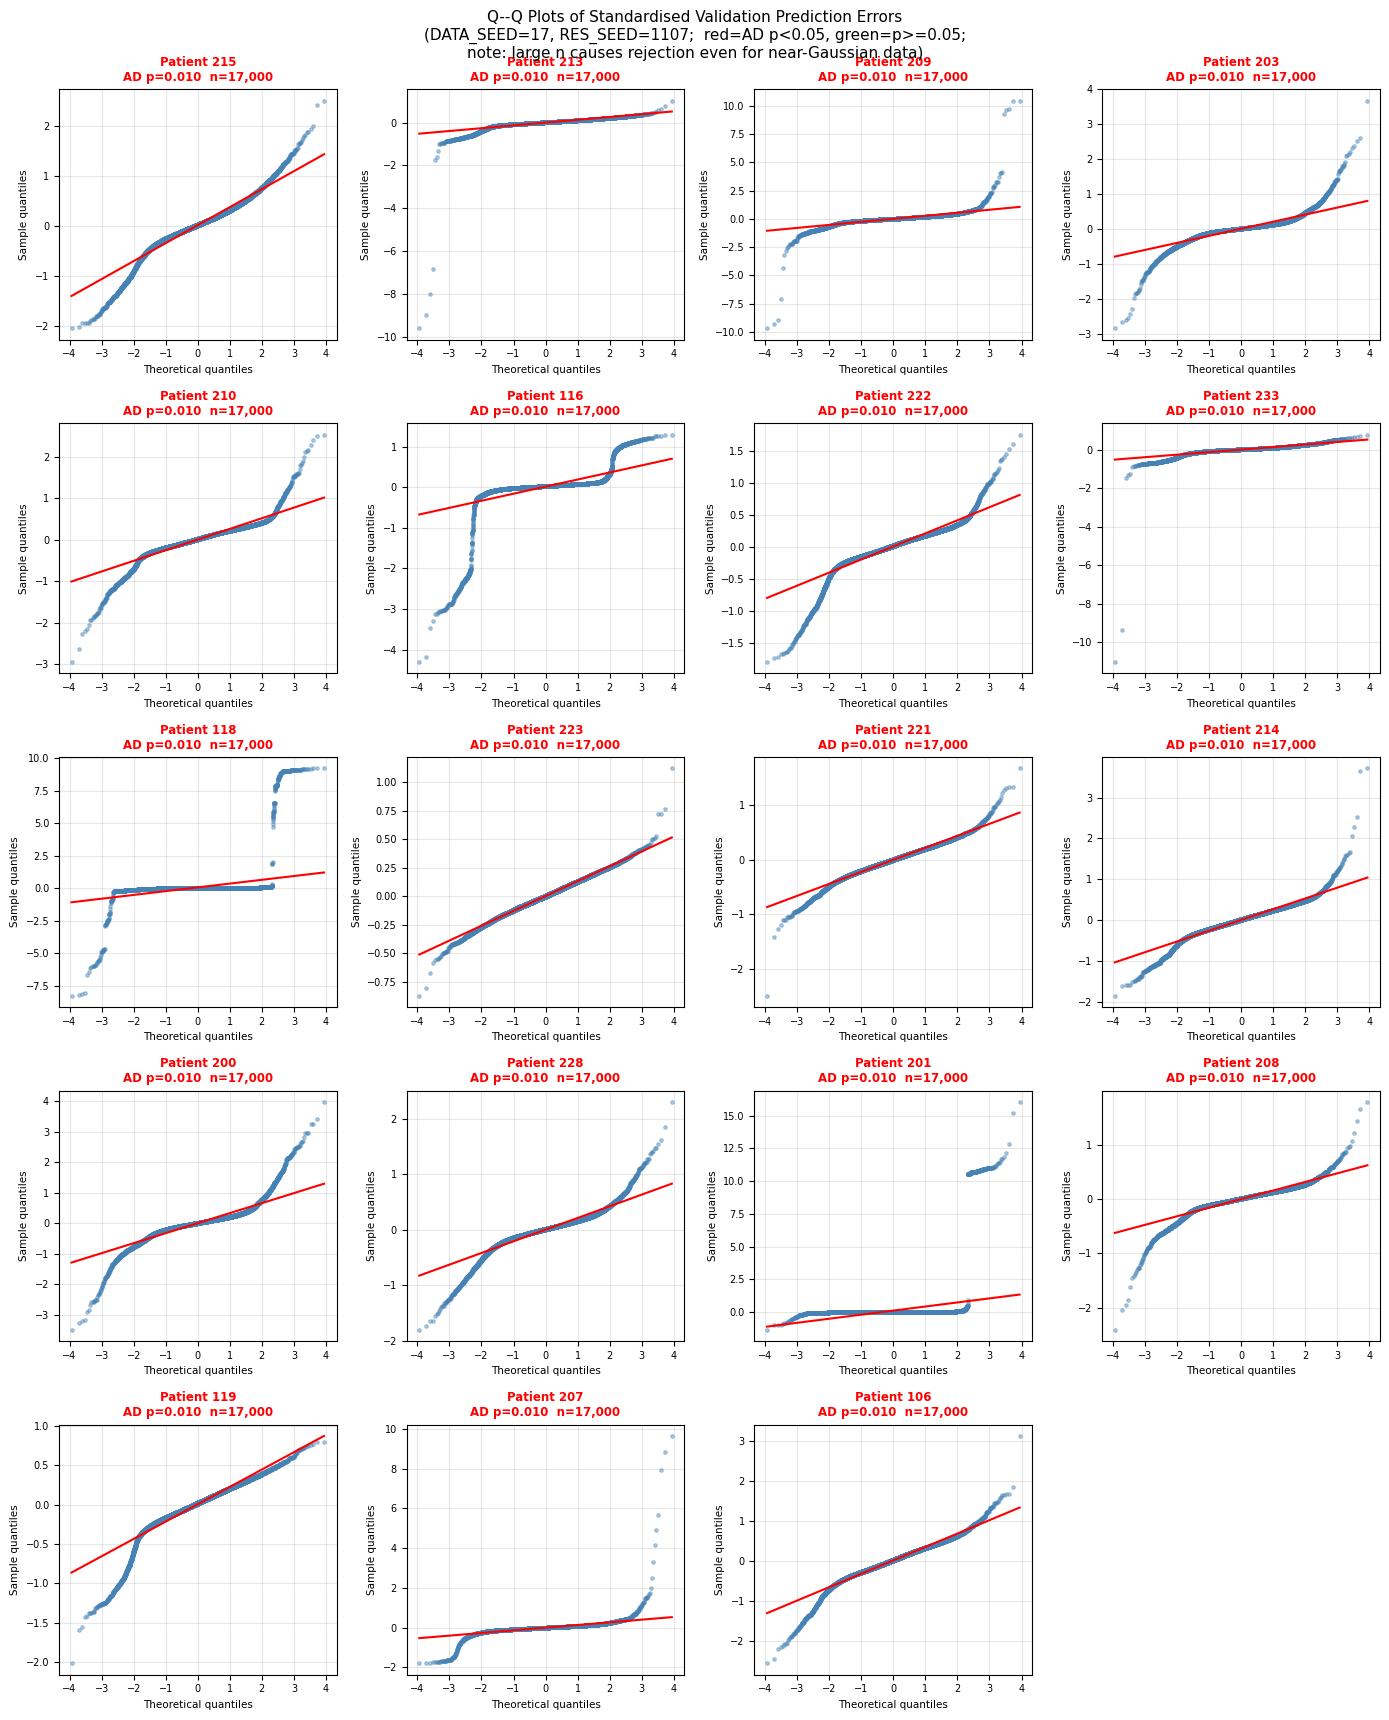

Saved Fig1


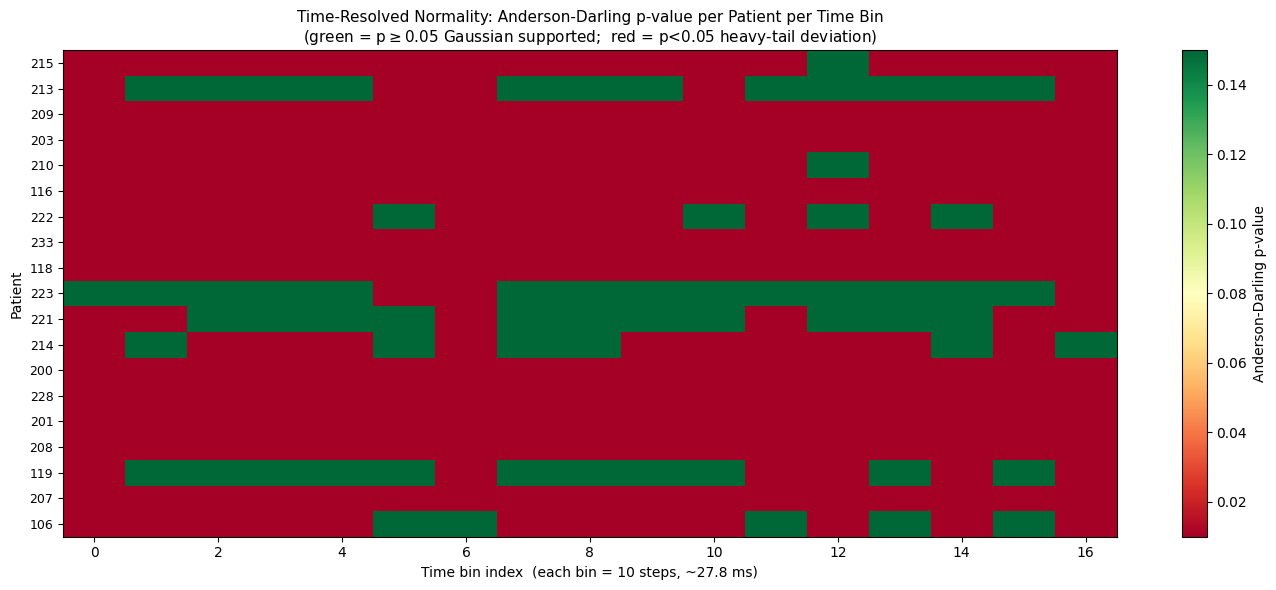

Saved Fig2


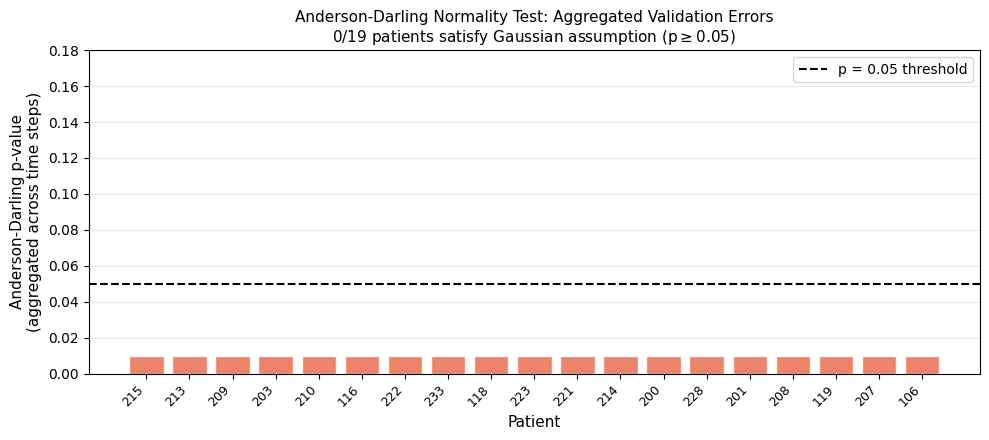

Saved Fig3


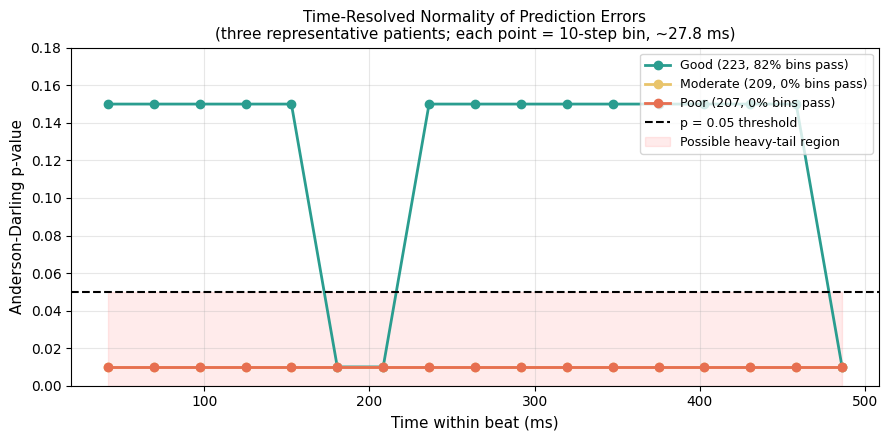

Saved Fig4

PAPER-READY NUMBERS
DATA_SEED=17, RES_SEED=1107
Patients tested          : 19
Pass (p>=0.05)           : 0/19
Mean AD p-value          : 0.0100 +/- 0.0000
Min AD p (patient 215)    : 0.0100
Max AD p (patient 215)    : 0.0100

Time-bin pass (p>=0.05)  : 20.1%
Time-bin mean p          : 0.0382
Time-bin std  p          : 0.0561

Per-patient fraction of bins passing:
  Patient 215  : 6%
  Patient 213  : 71%
  Patient 209  : 0%
  Patient 203  : 0%
  Patient 210  : 6%
  Patient 116  : 0%
  Patient 222  : 24%
  Patient 233  : 0%
  Patient 118  : 0%
  Patient 223  : 82%
  Patient 221  : 65%
  Patient 214  : 35%
  Patient 200  : 0%
  Patient 228  : 0%
  Patient 201  : 0%
  Patient 208  : 0%
  Patient 119  : 65%
  Patient 207  : 0%
  Patient 106  : 29%


In [1]:
#!/usr/bin/env python
# coding: utf-8

# ==========================================================
# GAUSSIAN ERROR ASSUMPTION VALIDATION — NOTEBOOK VERSION
# Runs all 19 patients in one script.
# Seeds changed from old seed=46 to:
#   DATA_SEED = 17   (default_rng — matches main swarm)
#   RES_SEED  = 1107 (default_rng — first reservoir seed)
# Saves all intermediate data so figures can be rerun instantly.
# ==========================================================

import numpy as np
import os
import json
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import norm, anderson, probplot
from sklearn.decomposition import PCA
from numpy.random import default_rng
import wfdb
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# CONFIG
# ==========================================================

selected_patients = [
    '215','213','209','203','210','116','222','233',
    '118','223','221','214','200','228','201','208',
    '119','207','106'
]

data_folder       = 'mitdb_data_full'
annotation_folder = 'mit-bih-arrhythmia-database-1.0.0'
NORMAL_BEATS      = ['.', 'N', 'L', 'R', 'e', 'j']
ARRHYTHMIC_BEATS  = ['A', 'a', 'J', 'S', 'V', 'E', 'F']

fs          = 360
beat_length = 180
input_len   = 10
pred_len    = 1
steps       = 1
N_res       = 10

# ---- CHANGED: was seed=46 + np.random.seed ----
DATA_SEED = 17    # default_rng — matches main swarm data split
RES_SEED  = 1107  # default_rng — first reservoir seed in swarm

num_train_beats = 500
num_val_beats   = 100
TIME_BIN_SIZE   = 10   # steps per AD bin (~27.8 ms)

fig_dir  = "figures_gaussian_validation"
data_dir = "data_gaussian_validation"   # saved intermediate data
os.makedirs(fig_dir,  exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

# ==========================================================
# HELPERS — exact copies from main swarm script
# ==========================================================

def get_segments(signal, ann_samples, ann_symbols, beat_length, targets):
    segs, idxs = [], []
    for s, sym in zip(ann_samples, ann_symbols):
        if sym in targets and s >= beat_length:
            segs.append(signal[s - beat_length:s])
            idxs.append(s)
    return segs, idxs

def sliding_data(seg, input_len, pred_len):
    X_y, Y = [], []
    for t in range(len(seg) - input_len - pred_len + 1):
        X_y.append(seg[t:t+input_len])
        Y.append(seg[t+input_len:t+input_len+pred_len])
    return np.array(X_y).T, np.array(Y).T

def rossler_system(t, X, params, N):
    X    = X.reshape(N, 3)
    dxdt = (1/params[:,3])*(-X[:,1]-X[:,2])
    dydt = (1/params[:,3])*(X[:,0]+params[:,0]*X[:,1])
    dzdt = (1/params[:,3])*(params[:,1]+X[:,2]*(X[:,0]-params[:,2]))
    return np.stack([dxdt, dydt, dzdt], axis=1).flatten()

def compute_phi(X_norm, N, steps, R=None, params=None):
    M, D        = X_norm.shape
    params_used = params[:N]
    if R is None:
        R = np.random.uniform(-1, 1, size=(3*N, M))
    phi = np.zeros((3*N, D))
    for i in range(D):
        u      = R @ X_norm[:, i]
        t_eval = np.linspace(0, 20, 100*steps)
        sol    = solve_ivp(rossler_system,
                           [t_eval[0], t_eval[-1]], u,
                           t_eval=t_eval,
                           args=(params_used, N),
                           rtol=1e-6, atol=1e-9)
        phi[:, i] = sol.y[:, -1]
    return phi, R, params_used

def train_dsrn(X_norm, Y_norm, N, steps, params_fixed):
    phi, R, params_used = compute_phi(X_norm, N, steps, params=params_fixed)
    S, _, _, _          = np.linalg.lstsq(phi.T, Y_norm.T, rcond=None)
    return S.T, R, params_used

def predict_dsrn(X_norm, S, R, params, N, steps):
    phi, _, _ = compute_phi(X_norm, N, steps, R=R, params=params)
    return S @ phi

def ad_pvalue(data):
    """Approximate AD p-value by interpolating critical values."""
    data = np.array(data)
    data = data[np.isfinite(data)]
    if len(data) < 8:
        return np.nan
    result     = anderson(data, dist='norm')
    sig_levels = np.array([0.15, 0.10, 0.05, 0.025, 0.01])
    crit_vals  = result.critical_values
    stat       = result.statistic
    if stat <= crit_vals[0]:  return 0.15
    if stat >= crit_vals[-1]: return 0.01
    return float(np.interp(stat, crit_vals[::-1], sig_levels[::-1]))

# ==========================================================
# MAIN LOOP — all 19 patients
# Saves per-patient data so figures can be regenerated instantly
# ==========================================================

patient_zscores = {}   # record -> all z-scores
patient_ad_agg  = {}   # record -> aggregated AD p-value
patient_ad_t    = {}   # record -> per-time-bin AD p-values

summary_rows = []

for record in selected_patients:
    # Check if already computed
    cache_path = os.path.join(data_dir, "{}.npz".format(record))

    if os.path.exists(cache_path):
        print("Loading cached data for {}...".format(record))
        cache = np.load(cache_path, allow_pickle=True)
        patient_zscores[record] = cache["all_z"]
        patient_ad_agg[record]  = float(cache["ad_agg"])
        patient_ad_t[record]    = cache["ad_t"]
        print("  AD agg p={:.4f}  n_z={:,}".format(
            patient_ad_agg[record], len(patient_zscores[record])))
        summary_rows.append({
            "record": record,
            "ad_agg": patient_ad_agg[record],
            "n_z":    len(patient_zscores[record]),
        })
        continue

    print("Processing {}...".format(record))

    # ---- Load ----
    try:
        ann    = wfdb.rdann(os.path.join(annotation_folder, record),
                            extension='atr')
        signal = np.load(os.path.join(data_folder,
                         '{}.npy'.format(record)))[:, 0]
    except Exception as e:
        print("  Skipping: {}".format(e))
        continue

    norm_segs, _ = get_segments(signal, ann.sample, ann.symbol,
                                 beat_length, NORMAL_BEATS)
    if len(norm_segs) < num_train_beats + num_val_beats:
        print("  Skipping: not enough normal beats")
        continue

    # ---- CHANGED: default_rng instead of np.random.seed ----
    rng_data = default_rng(DATA_SEED)
    rng_res  = default_rng(RES_SEED)

    idx = np.arange(len(norm_segs))
    rng_data.shuffle(idx)   # CHANGED: was np.random.shuffle(idx)
    val_idx   = idx[:num_val_beats]
    train_idx = idx[num_val_beats:num_val_beats+num_train_beats]

    train_segs = np.array([norm_segs[i] for i in train_idx])
    val_segs   = np.array([norm_segs[i] for i in val_idx])

    # ---- CHANGED: rng_res.uniform instead of np.random.uniform ----
    stable_range  = [(0.02,0.07),(0.02,0.07),(6.0,7.0)]
    chaotic_range = [(0.18,0.22),(0.18,0.22),(5.5,5.9)]
    mix_ratio     = 1
    hybrid_range  = [(sl+mix_ratio*(cl-sl), sh+mix_ratio*(ch-sh))
                     for (sl,sh),(cl,ch) in zip(stable_range,chaotic_range)]
    tau_range     = (0.8, 2.0)

    params_fixed = np.array([
        [rng_res.uniform(*r) for r in hybrid_range] +
        [rng_res.uniform(*tau_range)]
        for _ in range(200)
    ])

    # ---- Training ----
    all_X, all_Y = [], []
    for seg in train_segs:
        if len(seg) < input_len + pred_len:
            continue
        X, Y = sliding_data(seg, input_len, pred_len)
        all_X.append(X); all_Y.append(Y)
    if not all_X:
        continue

    X_raw = np.hstack(all_X)
    Y_raw = np.hstack(all_Y)
    pca   = PCA(n_components=3)
    X_pca = pca.fit_transform(X_raw.T).T

    # CHANGED: no np.random.seed(seed) before train — rng_res handles it
    S, R, params = train_dsrn(X_pca, Y_raw, N_res, steps, params_fixed)

    # ---- Validation predictions ----
    L               = beat_length - input_len
    val_pred_matrix = []

    for seg in val_segs:
        if len(seg) < input_len + pred_len:
            continue
        preds = []
        for t in range(input_len, beat_length):
            y_in  = seg[t-input_len:t].reshape(-1,1)
            y_pca = pca.transform(y_in.T).T
            y_pred = predict_dsrn(y_pca, S, R, params, N_res, steps)
            preds.append(float(y_pred.flatten()[0]))
        val_pred_matrix.append(preds[:L])

    if not val_pred_matrix:
        continue

    val_pred_matrix = np.array([p[:L] for p in val_pred_matrix])
    val_true_matrix = np.array([seg[input_len:input_len+L]
                                  for seg in val_segs
                                  if len(seg) >= input_len+L])

    n               = min(val_pred_matrix.shape[0],
                          val_true_matrix.shape[0])
    val_pred_matrix = val_pred_matrix[:n]
    val_true_matrix = val_true_matrix[:n]

    # ---- mu_i, sigma_i as in main script ----
    mu_i    = val_pred_matrix.mean(axis=0)
    sigma_i = val_pred_matrix.std(axis=0) + 1e-8

    # ---- Standardised errors ----
    zscores_t = (val_pred_matrix - val_true_matrix) / sigma_i[np.newaxis, :]

    all_z  = zscores_t.flatten()
    all_z  = all_z[np.isfinite(all_z)]
    ad_agg = ad_pvalue(all_z)

    # ---- Per-time-bin AD ----
    n_bins = L // TIME_BIN_SIZE
    ad_t   = []
    for b in range(n_bins):
        bin_z = zscores_t[:, b*TIME_BIN_SIZE:(b+1)*TIME_BIN_SIZE].flatten()
        bin_z = bin_z[np.isfinite(bin_z)]
        ad_t.append(ad_pvalue(bin_z))
    ad_t = np.array(ad_t)

    # ---- Cache to disk ----
    np.savez(cache_path,
             all_z=all_z,
             ad_agg=np.array(ad_agg),
             ad_t=ad_t)

    patient_zscores[record] = all_z
    patient_ad_agg[record]  = ad_agg
    patient_ad_t[record]    = ad_t

    summary_rows.append({
        "record": record,
        "ad_agg": ad_agg,
        "n_z":    len(all_z),
    })

    print("  AD agg p={:.4f}  n_z={:,}  bins={} ({:.0f}% pass)".format(
        ad_agg, len(all_z), n_bins,
        100*np.mean(ad_t >= 0.05)))

# Save summary CSV
pd.DataFrame(summary_rows).to_csv(
    os.path.join(data_dir, "summary.csv"), index=False)
print("\nAll patients processed. Cached to: {}".format(data_dir))

# ==========================================================
# FIGURE 1 — Q-Q grid (one panel per patient)
# ==========================================================

n_pats = len(patient_zscores)
n_cols = 4
n_rows = int(np.ceil(n_pats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols*3.5, n_rows*3.5))
axes = axes.flatten()

for pi, record in enumerate(selected_patients):
    if record not in patient_zscores:
        axes[pi].set_visible(False)
        continue
    ax = axes[pi]
    z  = patient_zscores[record]

    (osm, osr), (slope, intercept, _) = probplot(z, dist='norm')
    ax.scatter(osm, osr, s=6, alpha=0.4, color='steelblue', zorder=2)
    xlim = np.array([osm[0], osm[-1]])
    ax.plot(xlim, slope*xlim+intercept, 'r-', linewidth=1.5, zorder=3)

    p_val = patient_ad_agg[record]
    p_str = "p={:.3f}".format(p_val) if p_val < 0.15 else "p>0.15"
    c_txt = 'green' if p_val >= 0.05 else 'red'

    ax.set_title("Patient {}\nAD {}  n={:,}".format(record, p_str, len(z)),
                 fontsize=8.5, color=c_txt, fontweight='bold')
    ax.set_xlabel("Theoretical quantiles", fontsize=7.5)
    ax.set_ylabel("Sample quantiles",      fontsize=7.5)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

for ax in axes[n_pats:]:
    ax.set_visible(False)

fig.suptitle(
    "Q--Q Plots of Standardised Validation Prediction Errors\n"
    "(DATA_SEED={}, RES_SEED={};  red=AD p<0.05, green=p>=0.05;\n"
    "note: large n causes rejection even for near-Gaussian data)".format(
        DATA_SEED, RES_SEED),
    fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "Fig1_QQ_all_patients_1.pdf"),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(fig_dir, "Fig1_QQ_all_patients_1.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved Fig1")

# ==========================================================
# FIGURE 2 — AD heatmap: patients x time bins
# ==========================================================

records_list = [r for r in selected_patients if r in patient_ad_t]
n_bins_max   = max(len(patient_ad_t[r]) for r in records_list)

heatmap = np.full((len(records_list), n_bins_max), np.nan)
for pi, rec in enumerate(records_list):
    v = patient_ad_t[rec]
    heatmap[pi, :len(v)] = v

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap, aspect='auto', cmap='RdYlGn',
               vmin=0.01, vmax=0.15)
plt.colorbar(im, ax=ax, label="Anderson-Darling p-value")
ax.set_yticks(range(len(records_list)))
ax.set_yticklabels(records_list, fontsize=9)
ax.set_xlabel(
    "Time bin index  (each bin = {} steps, ~{:.1f} ms)".format(
        TIME_BIN_SIZE, TIME_BIN_SIZE*1000/fs),
    fontsize=10)
ax.set_ylabel("Patient", fontsize=10)
ax.set_title(
    "Time-Resolved Normality: Anderson-Darling p-value per Patient per Time Bin\n"
    "(green = p$\\geq$0.05 Gaussian supported;  "
    "red = p<0.05 heavy-tail deviation)",
    fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "Fig2_AD_heatmap_1.pdf"),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(fig_dir, "Fig2_AD_heatmap_1.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved Fig2")

# ==========================================================
# FIGURE 3 — Per-patient AD bar chart (aggregated)
# ==========================================================

records_sorted = sorted(
    [r for r in selected_patients if r in patient_ad_agg],
    key=lambda r: patient_ad_agg[r])
pvals_sorted = [patient_ad_agg[r] for r in records_sorted]
colors_bar   = ['#2a9d8f' if p >= 0.05 else '#e76f51'
                for p in pvals_sorted]
n_pass = sum(p >= 0.05 for p in pvals_sorted)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(records_sorted, pvals_sorted,
       color=colors_bar, edgecolor='white', alpha=0.85)
ax.axhline(0.05, color='black', linestyle='--', linewidth=1.5,
           label='p = 0.05 threshold')
ax.set_ylabel("Anderson-Darling p-value\n(aggregated across time steps)",
              fontsize=11)
ax.set_xlabel("Patient", fontsize=11)
ax.set_xticklabels(records_sorted, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 0.18)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
ax.set_title(
    "Anderson-Darling Normality Test: Aggregated Validation Errors\n"
    "{}/{} patients satisfy Gaussian assumption (p$\\geq$0.05)".format(
        n_pass, len(pvals_sorted)),
    fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "Fig3_AD_bar_1.pdf"),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(fig_dir, "Fig3_AD_bar_1.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved Fig3")

# ==========================================================
# FIGURE 4 — Time-resolved AD: 3 representative patients
# ==========================================================

frac_pass_dict = {
    rec: np.nanmean(patient_ad_t[rec] >= 0.05)
    for rec in records_list
}
sorted_by_frac = sorted(frac_pass_dict.items(), key=lambda x: -x[1])
rep_good = sorted_by_frac[0][0]
rep_mid  = sorted_by_frac[len(sorted_by_frac)//2][0]
rep_bad  = sorted_by_frac[-1][0]

fig, ax = plt.subplots(figsize=(9, 4.5))
palette  = {'Good':'#2a9d8f', 'Moderate':'#e9c46a', 'Poor':'#e76f51'}

for label, rec, color in [
    ('Good ({}, {:.0f}% bins pass)'.format(
        rep_good, 100*frac_pass_dict[rep_good]),
     rep_good, palette['Good']),
    ('Moderate ({}, {:.0f}% bins pass)'.format(
        rep_mid, 100*frac_pass_dict[rep_mid]),
     rep_mid, palette['Moderate']),
    ('Poor ({}, {:.0f}% bins pass)'.format(
        rep_bad, 100*frac_pass_dict[rep_bad]),
     rep_bad, palette['Poor']),
]:
    ad_vals = patient_ad_t[rec]
    t_ms    = (np.arange(len(ad_vals))*TIME_BIN_SIZE +
               input_len + TIME_BIN_SIZE/2) * 1000/fs
    ax.plot(t_ms, ad_vals, 'o-', color=color, linewidth=2,
            markersize=6, label=label)

ax.axhline(0.05, color='black', linestyle='--', linewidth=1.5,
           label='p = 0.05 threshold')
ax.fill_between([t_ms[0], t_ms[-1]], 0, 0.05,
                alpha=0.08, color='red',
                label='Possible heavy-tail region')
ax.set_xlabel("Time within beat (ms)", fontsize=11)
ax.set_ylabel("Anderson-Darling p-value", fontsize=11)
ax.set_title(
    "Time-Resolved Normality of Prediction Errors\n"
    "(three representative patients; each point = {}-step bin, ~{:.1f} ms)".format(
        TIME_BIN_SIZE, TIME_BIN_SIZE*1000/fs),
    fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.18)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "Fig4_AD_time_resolved_1.pdf"),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(fig_dir, "Fig4_AD_time_resolved_1.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved Fig4")

# ==========================================================
# PRINT PAPER-READY NUMBERS
# ==========================================================

print("\n" + "="*60)
print("PAPER-READY NUMBERS")
print("="*60)
print("DATA_SEED={}, RES_SEED={}".format(DATA_SEED, RES_SEED))

pvals = [patient_ad_agg[r] for r in selected_patients
         if r in patient_ad_agg]
print("Patients tested          : {}".format(len(pvals)))
print("Pass (p>=0.05)           : {}/{}".format(
    sum(p >= 0.05 for p in pvals), len(pvals)))
print("Mean AD p-value          : {:.4f} +/- {:.4f}".format(
    np.nanmean(pvals), np.nanstd(pvals)))
print("Min AD p (patient {})    : {:.4f}".format(
    min(patient_ad_agg, key=patient_ad_agg.get),
    min(pvals)))
print("Max AD p (patient {})    : {:.4f}".format(
    max(patient_ad_agg, key=patient_ad_agg.get),
    max(pvals)))

all_bin_p = np.concatenate([patient_ad_t[r]
                              for r in records_list])
all_bin_p = all_bin_p[np.isfinite(all_bin_p)]
print("\nTime-bin pass (p>=0.05)  : {:.1f}%".format(
    100*np.mean(all_bin_p >= 0.05)))
print("Time-bin mean p          : {:.4f}".format(np.nanmean(all_bin_p)))
print("Time-bin std  p          : {:.4f}".format(np.nanstd(all_bin_p)))

print("\nPer-patient fraction of bins passing:")
for rec in selected_patients:
    if rec in frac_pass_dict:
        print("  Patient {:5s}: {:.0f}%".format(
            rec, 100*frac_pass_dict[rec]))